In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (

accuracy_score,

classification_report,

confusion_matrix,

precision_score,

recall_score,

f1_score

)

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

import nltk

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

import joblib

nltk.download('stopwords')

nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
from google.colab import files

uploaded=files.upload()

Saving train_data.txt to train_data (1).txt
Saving test_data.txt to test_data (1).txt
Saving test_data_solution.txt to test_data_solution (1).txt
Saving description.txt to description (1).txt


In [4]:
train=pd.read_csv(

"train_data.txt",

sep=":::",

engine="python",

names=[

"ID",

"TITLE",

"GENRE",

"DESCRIPTION"

]

)

train.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [5]:
test=pd.read_csv(

"test_data.txt",

sep=":::",

engine="python",

names=[

"ID",

"TITLE",

"DESCRIPTION"

]

)

test.head()

,ID,TITLE,DESCRIPTION
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apar..."
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty ch..."
2,3,Off the Beaten Track (2010),One year in the life of Albin and his family ...
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with hi..."
4,5,Er nu zhai (1955),Before he was known internationally as a mart...


In [6]:
solution=pd.read_csv(

"test_data_solution.txt",

sep=":::",

engine="python",

names=[

"ID",

"TITLE",

"GENRE",

"DESCRIPTION"

]

)

solution.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Edgar's Lunch (1998),thriller,"L.R. Brane loves his life - his car, his apar..."
1,2,La guerra de papá (1977),comedy,"Spain, March 1964: Quico is a very naughty ch..."
2,3,Off the Beaten Track (2010),documentary,One year in the life of Albin and his family ...
3,4,Meu Amigo Hindu (2015),drama,"His father has died, he hasn't spoken with hi..."
4,5,Er nu zhai (1955),drama,Before he was known internationally as a mart...


In [7]:
description=pd.read_csv(

"description.txt",

sep=":::",

engine="python"

)

description.head()

Train data:
ID         TITLE  GENRE    DESCRIPTION
                  GENRE    DESCRIPTION
                  GENRE    DESCRIPTION
                  GENRE    DESCRIPTION
Test data: NaN    NaN             None

In [8]:
train.columns=train.columns.str.strip()

test.columns=test.columns.str.strip()

solution.columns=solution.columns.str.strip()

train["GENRE"]=train["GENRE"].str.strip()

train["DESCRIPTION"]=train["DESCRIPTION"].astype(str)

test["DESCRIPTION"]=test["DESCRIPTION"].astype(str)

In [9]:
print(train.shape)

train.info()

train.isnull().sum()

(54214, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54214 non-null  int64 
 1   TITLE        54214 non-null  object
 2   GENRE        54214 non-null  object
 3   DESCRIPTION  54214 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


,0
ID,0
TITLE,0
GENRE,0
DESCRIPTION,0


In [12]:
data=train[['DESCRIPTION','GENRE']]
data.head()

,DESCRIPTION,GENRE
0,Listening in to a conversation between his do...,drama
1,A brother and sister with a past incestuous r...,thriller
2,As the bus empties the students for their fie...,adult
3,To help their unemployed father make ends mee...,drama
4,The film's title refers not only to the un-re...,drama


In [13]:
stop_words=set(

stopwords.words(

'english'

)

)

lemmatizer=WordNetLemmatizer()

def clean_text(text):

 text=str(text).lower()

 text=re.sub(

 r"[^a-zA-Z]",

 " ",

 text

 )

 words=text.split()

 words=[

 lemmatizer.lemmatize(

 word

 )

 for word in words

 if word not in stop_words

 ]

 return " ".join(words)

In [16]:
data['clean_text']=data['DESCRIPTION'].apply(

clean_text

)

/tmp/ipykernel_11219/1782183338.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['clean_text']=data['DESCRIPTION'].apply(


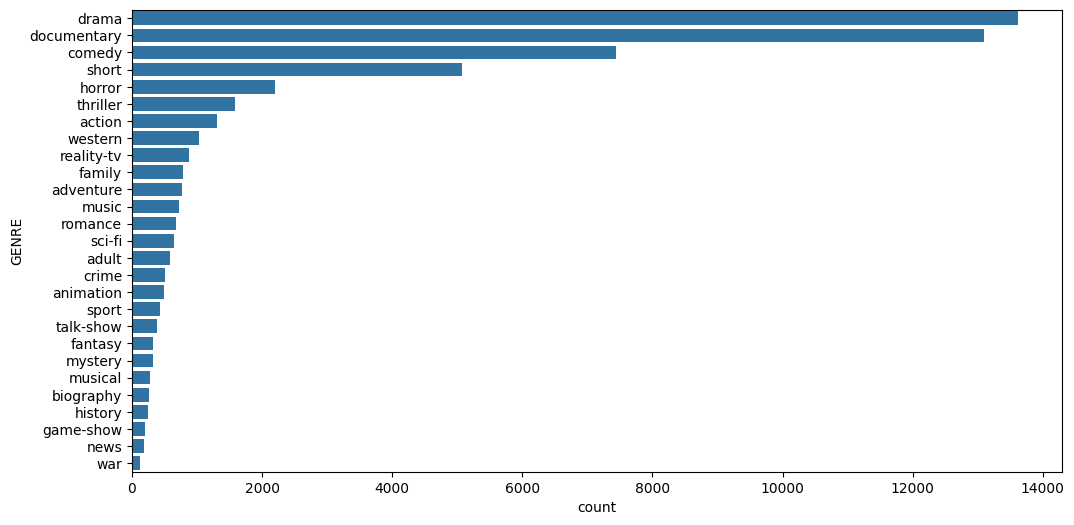

In [17]:
plt.figure(

figsize=(12,6)

)

sns.countplot(

y=data['GENRE'],

order=data['GENRE'].value_counts().index

)

plt.show()

In [19]:
tfidf=TfidfVectorizer(

max_features=10000,

ngram_range=(1,2)

)

X=tfidf.fit_transform(

data['clean_text']

)

y=data['GENRE']

In [20]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42,

stratify=y

)

print(X_train.shape)

print(X_test.shape)

(43371, 10000)
(10843, 10000)


In [21]:
nb=MultinomialNB()

nb.fit(

X_train,

y_train

)

pred_nb=nb.predict(

X_test

)

In [22]:
print(

"Accuracy:",

accuracy_score(

y_test,

pred_nb

)

)

print(

classification_report(

y_test,

pred_nb

)

)

Accuracy: 0.517568938485659
              precision    recall  f1-score   support

      action       0.67      0.04      0.07       263
       adult       0.50      0.03      0.06       118
   adventure       0.73      0.05      0.10       155
   animation       0.00      0.00      0.00       100
   biography       0.00      0.00      0.00        53
      comedy       0.52      0.44      0.48      1490
       crime       0.00      0.00      0.00       101
 documentary       0.56      0.90      0.69      2619
       drama       0.46      0.83      0.59      2723
      family       0.00      0.00      0.00       157
     fantasy       0.00      0.00      0.00        65
   game-show       1.00      0.03      0.05        39
     history       0.00      0.00      0.00        49
      horror       0.80      0.30      0.44       441
       music       0.67      0.01      0.03       146
     musical       0.00      0.00      0.00        55
     mystery       0.00      0.00      0.00        64

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
print(

"Precision:",

precision_score(

y_test,

pred_nb,

average='weighted'

)

)

print(

"Recall:",

recall_score(

y_test,

pred_nb,

average='weighted'

)

)

print(

"F1:",

f1_score(

y_test,

pred_nb,

average='weighted'

)

)

Precision: 0.49311575522110135
Recall: 0.517568938485659
F1: 0.4315139071258635


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


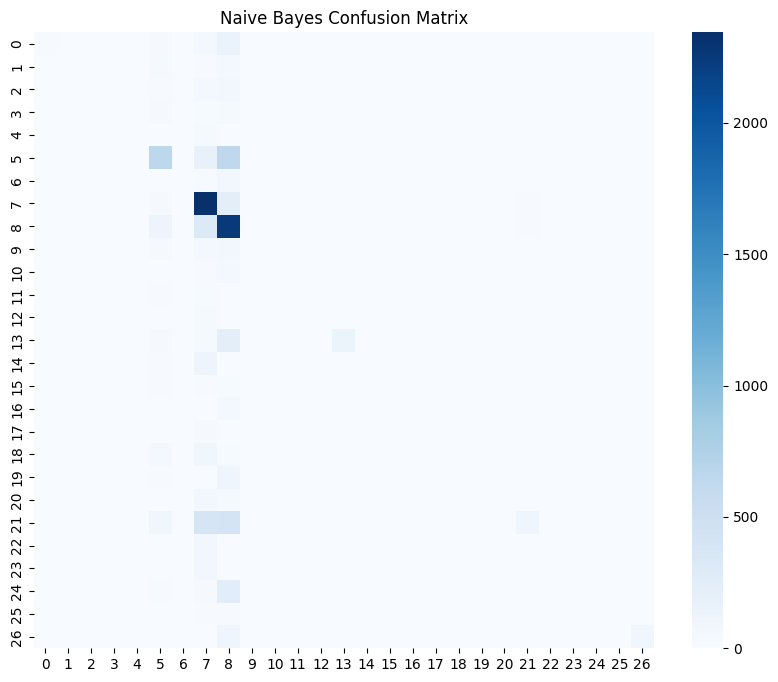

In [24]:
cm_nb=confusion_matrix(

y_test,

pred_nb

)

plt.figure(

figsize=(10,8)

)

sns.heatmap(

cm_nb,

cmap="Blues"

)

plt.title(

"Naive Bayes Confusion Matrix"

)

plt.show()

In [25]:
lr=LogisticRegression(

max_iter=3000

)

lr.fit(

X_train,

y_train

)

pred_lr=lr.predict(

X_test

)

In [26]:
print(

"Accuracy:",

accuracy_score(

y_test,

pred_lr

)

)

print(

classification_report(

y_test,

pred_lr

)

)

Accuracy: 0.582772295490178
              precision    recall  f1-score   support

      action       0.53      0.29      0.37       263
       adult       0.73      0.28      0.40       118
   adventure       0.53      0.12      0.19       155
   animation       0.47      0.07      0.12       100
   biography       0.00      0.00      0.00        53
      comedy       0.53      0.60      0.56      1490
       crime       0.20      0.02      0.04       101
 documentary       0.67      0.85      0.75      2619
       drama       0.54      0.78      0.64      2723
      family       0.57      0.08      0.14       157
     fantasy       0.00      0.00      0.00        65
   game-show       0.90      0.46      0.61        39
     history       0.00      0.00      0.00        49
      horror       0.68      0.59      0.63       441
       music       0.66      0.36      0.46       146
     musical       1.00      0.02      0.04        55
     mystery       0.00      0.00      0.00        64

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
print(

"Precision:",

precision_score(

y_test,

pred_lr,

average='weighted'

)

)

print(

"Recall:",

recall_score(

y_test,

pred_lr,

average='weighted'

)

)

print(

"F1:",

f1_score(

y_test,

pred_lr,

average='weighted'

)

)

Precision: 0.5572316871064391
Recall: 0.582772295490178
F1: 0.541355900906424


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


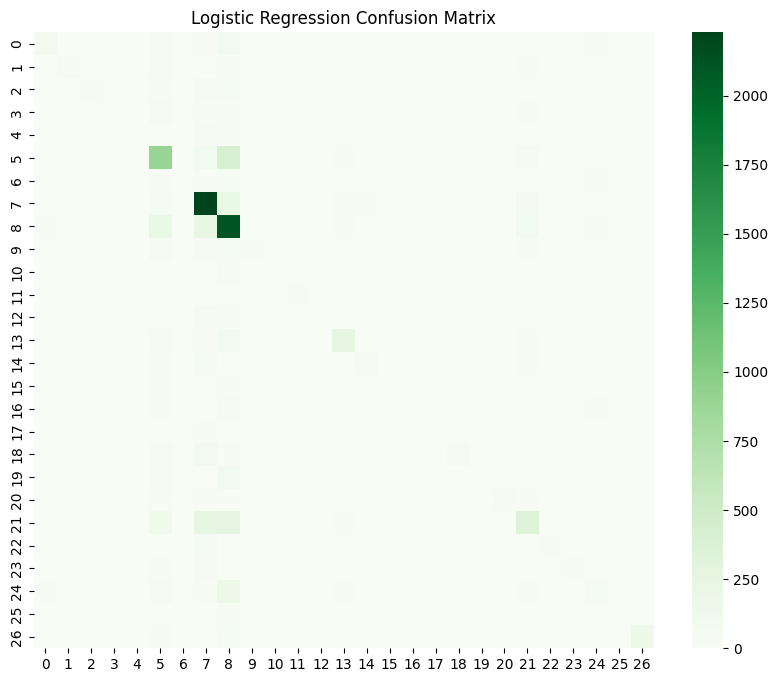

In [28]:
cm_lr=confusion_matrix(

y_test,

pred_lr

)

plt.figure(

figsize=(10,8)

)

sns.heatmap(

cm_lr,

cmap="Greens"

)

plt.title(

"Logistic Regression Confusion Matrix"

)

plt.show()

In [29]:
svm=LinearSVC()

svm.fit(

X_train,

y_train

)

pred_svm=svm.predict(

X_test

)

In [30]:
print(

"Accuracy:",

accuracy_score(

y_test,

pred_svm

)

)

print(

classification_report(

y_test,

pred_svm

)

)

Accuracy: 0.5715207968274463
              precision    recall  f1-score   support

      action       0.41      0.35      0.38       263
       adult       0.72      0.49      0.58       118
   adventure       0.36      0.20      0.26       155
   animation       0.27      0.15      0.19       100
   biography       0.00      0.00      0.00        53
      comedy       0.53      0.58      0.56      1490
       crime       0.30      0.07      0.11       101
 documentary       0.69      0.81      0.74      2619
       drama       0.57      0.69      0.62      2723
      family       0.27      0.15      0.19       157
     fantasy       0.08      0.02      0.03        65
   game-show       0.72      0.59      0.65        39
     history       0.50      0.04      0.08        49
      horror       0.62      0.62      0.62       441
       music       0.58      0.48      0.52       146
     musical       0.25      0.05      0.09        55
     mystery       0.07      0.02      0.03        6

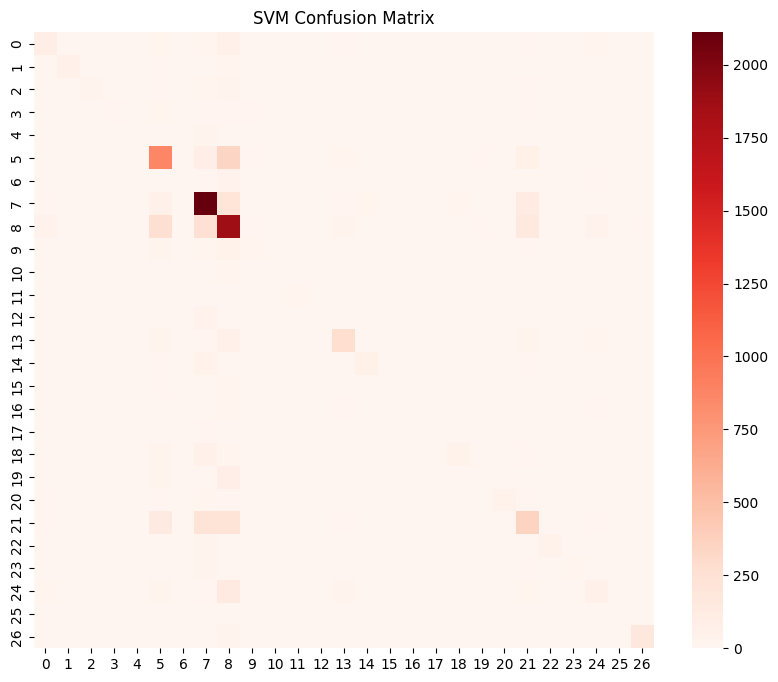

In [31]:
cm_svm=confusion_matrix(

y_test,

pred_svm

)

plt.figure(

figsize=(10,8)

)

sns.heatmap(

cm_svm,

cmap="Reds"

)

plt.title(

"SVM Confusion Matrix"

)

plt.show()

In [32]:
comparison=pd.DataFrame({

"Model":[

"Naive Bayes",

"Logistic Regression",

"SVM"

],

"Accuracy":[

accuracy_score(

y_test,

pred_nb

),

accuracy_score(

y_test,

pred_lr

),

accuracy_score(

y_test,

pred_svm

)

]

})

comparison

,Model,Accuracy
0,Naive Bayes,0.517569
1,Logistic Regression,0.582772
2,SVM,0.571521


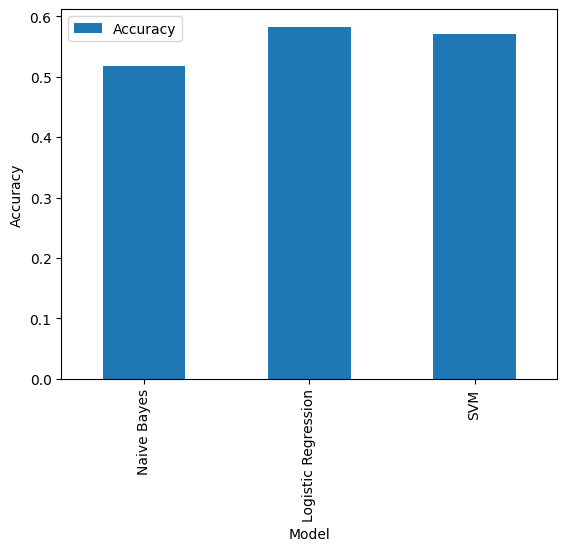

In [33]:
comparison.plot(

x="Model",

y="Accuracy",

kind="bar"

)

plt.ylabel(

"Accuracy"

)

plt.show()

In [34]:
scores={

"Naive Bayes":

accuracy_score(

y_test,

pred_nb

),

"Logistic Regression":

accuracy_score(

y_test,

pred_lr

),

"SVM":

accuracy_score(

y_test,

pred_svm

)

}

best_name=max(

scores,

key=scores.get

)

print(

"Best Model:",

best_name

)

if best_name=="Naive Bayes":

 best_model=nb

elif best_name=="Logistic Regression":

 best_model=lr

else:

 best_model=svm

joblib.dump(

best_model,

"best_model.pkl"

)

joblib.dump(

tfidf,

"tfidf.pkl"

)

Best Model: Logistic Regression


['tfidf.pkl']

In [35]:
model=joblib.load(

"best_model.pkl"

)

vectorizer=joblib.load(

"tfidf.pkl"

)

In [ ]:
while True:

 text=input(

 "Enter movie plot: "

 )

 cleaned=clean_text(

 text

 )

 vector=vectorizer.transform(

 [cleaned]

 )

 prediction=model.predict(

 vector

 )[0]

 confidence=0

 try:

  score=model.decision_function(

  vector

  )

  confidence=float(

  np.max(score)

  )

 except:

  confidence=0

 threshold=0.5

 if confidence<threshold:

  print(

  "\nGenre: Not in our database"

  )

 else:

  print(

  "\nPredicted Genre:",

  prediction

  )

  print(

  "Confidence:",

  round(

  confidence,

  2

  )

  )

 choice=input(

 "\nContinue? y/n : "

 )

 if choice!="y":

  break

Enter movie plot: A group of college students travel to an abandoned house for a weekend trip and discover something terrifying living beneath the building.

Predicted Genre: horror
Confidence: 6.46

Continue? y/n : y
Enter movie plot: Two best friends accidentally become famous on social media and try to maintain their popularity while hiding their real identities.

Predicted Genre: comedy
Confidence: 4.62
